# Explore Historical Data and Select Model Features

This notebook explores the prepared Mont Blanc historical glacier dataset before model training. The analysis examines the mass-balance target, climate predictors, relationships between variables, temporal patterns, and differences among glacier records. The results will be used to select a defensible set of features for the initial machine-learning model.

In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("..") / "data"
PROCESSED_DIR = DATA_DIR / "processed"

historical_data_file = (
    PROCESSED_DIR
    / "MontBlanc_Historical_Model_Data_1968-2015.csv"
)

data = pd.read_csv(historical_data_file)

print("Shape:", data.shape)
print(
    "Years:",
    data["hydrological_year"].min(),
    "-",
    data["hydrological_year"].max()
)
print("Unique glacier records:", data["glacier_index"].nunique())

data.head()

Shape: (2724, 14)
Years: 1968 - 2015
Unique glacier records: 58


,hydrological_year,glacier_index,annual_temperature_c,winter_temperature_c,summer_temperature_c,annual_precipitation_mm,winter_precipitation_mm,summer_precipitation_mm,RGI_ID,GLIMS_ID,glacier_name,latitude,longitude,mass_balance
0,1968,423,1.040538,-4.237914,6.318990,1622.972595,787.011292,835.961303,3344,G006776E45799N,de la Berangere,45.799,6.776,1.020175
1,1968,424,1.064644,-4.219128,6.348415,1633.635529,790.549427,843.086102,3601,G006778E45809N,d'Armancette,45.809,6.778,0.992590
2,1968,427,1.069756,-4.218176,6.357689,1638.001434,791.076965,846.924469,3650,G006783E45817N,de Covagnet,45.817,6.783,1.047586
3,1968,429,0.959309,-4.310709,6.229326,1593.901842,774.321153,819.580689,3651,G006784E45784N,de Tre la Tete 1,45.784,6.784,-0.154915
4,1968,431,1.077550,-4.213031,6.368132,1642.061705,792.160762,849.900943,3276,G006785E45822N,du Miage 1,45.822,6.785,-0.445979


## Explore Glacier Mass Balance

The mass-balance target is examined first to understand its distribution, range, and central tendency before evaluating potential predictor variables.

In [18]:
# Summary statistics for the mass-balance target.
print(data["mass_balance"].describe())

print(
    "\nNegative mass-balance observations:",
    (data["mass_balance"] < 0).sum()
)

print(
    "Positive mass-balance observations:",
    (data["mass_balance"] > 0).sum()
)

print(
    "Zero mass-balance observations:",
    (data["mass_balance"] == 0).sum()
)

count    2724.000000
mean       -0.717264
std         0.976092
min        -3.639968
25%        -1.420383
50%        -0.721048
75%        -0.054481
max         2.359916
Name: mass_balance, dtype: float64

Negative mass-balance observations: 2086
Positive mass-balance observations: 638
Zero mass-balance observations: 0


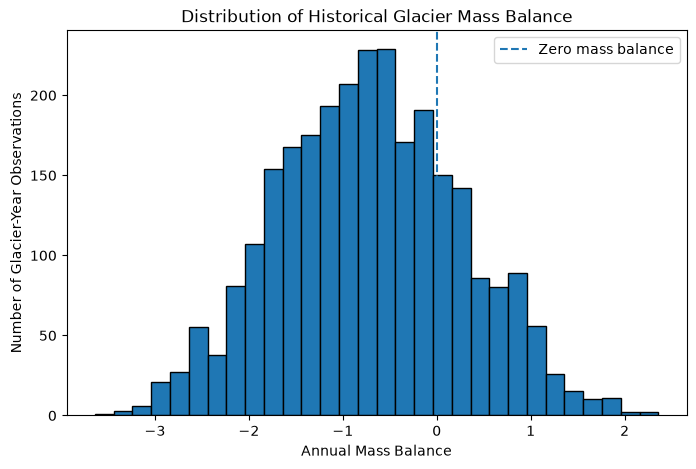

In [19]:
# Plot the distribution of glacier mass balance.
plt.figure(figsize=(8, 5))

plt.hist(
    data["mass_balance"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Zero mass balance"
)

plt.xlabel("Annual Mass Balance")
plt.ylabel("Number of Glacier-Year Observations")
plt.title("Distribution of Historical Glacier Mass Balance")
plt.legend()

plt.show()

### Mass-Balance Distribution

Historical glacier mass balance is centered below zero, with a mean and median of approximately -0.72. Most glacier-year observations therefore represent years with net ice loss, although positive mass-balance years are also present. The distribution is continuous across zero and does not show an obvious separate cluster or unusual concentration of extreme observations. The original mass-balance values will therefore be retained without transformation for the initial modeling analysis.

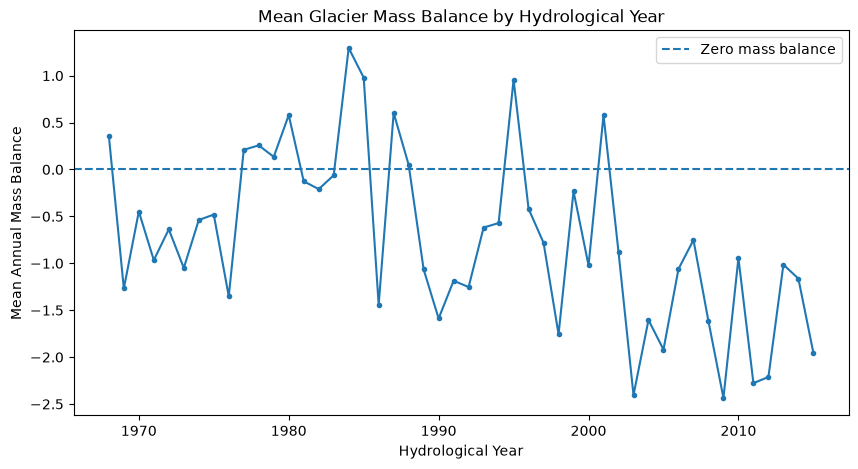

In [20]:
# Calculate mean mass balance across glacier records for each year.
annual_mean_smb = (
    data.groupby("hydrological_year")["mass_balance"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    annual_mean_smb.index,
    annual_mean_smb.values,
    marker="o",
    markersize=3
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Zero mass balance"
)

plt.xlabel("Hydrological Year")
plt.ylabel("Mean Annual Mass Balance")
plt.title("Mean Glacier Mass Balance by Hydrological Year")
plt.legend()

plt.show()

### Mass Balance Over Time

Mass balance changes quite a bit from year to year, but the later years are noticeably more negative than the earlier part of the dataset. Positive years still occur throughout the record, but they become much less common toward the end. Because the data have a clear time component, the model should be tested on later years instead of randomly mixing observations from all years into the training and test sets.

## Explore Climate Features

The temperature and precipitation features are compared to check their ranges and look for possible overlap between variables before choosing inputs for the model.

In [21]:
climate_columns = [
    "annual_temperature_c",
    "winter_temperature_c",
    "summer_temperature_c",
    "annual_precipitation_mm",
    "winter_precipitation_mm",
    "summer_precipitation_mm"
]

climate_summary = data[climate_columns].describe().T

climate_summary[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

,mean,std,min,25%,50%,75%,max
annual_temperature_c,1.32,0.71,-0.29,0.80,1.22,1.76,3.58
winter_temperature_c,-4.62,0.90,-6.62,-5.30,-4.71,-4.00,-1.48
summer_temperature_c,7.26,1.02,4.88,6.50,7.36,7.87,9.85
annual_precipitation_mm,1627.33,227.06,1084.06,1462.34,1588.86,1810.93,2172.39
winter_precipitation_mm,826.68,188.96,432.04,701.68,792.35,955.79,1305.80
summer_precipitation_mm,800.64,98.78,560.80,723.79,800.68,867.04,1077.66


In [22]:
# Compare the climate features with each other and with mass balance.
correlation_columns = climate_columns + ["mass_balance"]

correlations = (
    data[correlation_columns]
    .corr()
    .round(3)
)

correlations

,annual_temperature_c,winter_temperature_c,summer_temperature_c,annual_precipitation_mm,winter_precipitation_mm,summer_precipitation_mm,mass_balance
annual_temperature_c,1.000,0.705,0.779,-0.048,-0.074,0.030,-0.464
winter_temperature_c,0.705,1.000,0.105,0.065,0.037,0.079,-0.079
summer_temperature_c,0.779,0.105,1.000,-0.125,-0.136,-0.028,-0.580
annual_precipitation_mm,-0.048,0.065,-0.125,1.000,0.903,0.571,0.547
winter_precipitation_mm,-0.074,0.037,-0.136,0.903,1.000,0.163,0.498
summer_precipitation_mm,0.030,0.079,-0.028,0.571,0.163,1.000,0.304
mass_balance,-0.464,-0.079,-0.580,0.547,0.498,0.304,1.000


### Climate Relationships

Summer temperature has the strongest temperature relationship with mass balance, while winter temperature has very little correlation on its own. Annual and winter precipitation both have fairly strong positive relationships with mass balance. Some of the climate variables are also strongly related to each other, especially annual and winter precipitation, so using every climate feature may add unnecessary overlap to the model.

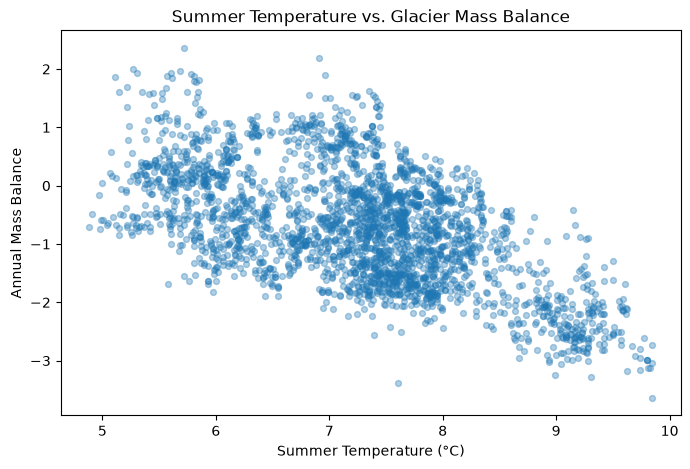

In [23]:
# Compare summer temperature with glacier mass balance.
plt.figure(figsize=(8, 5))

plt.scatter(
    data["summer_temperature_c"],
    data["mass_balance"],
    alpha=0.35,
    s=18
)

plt.xlabel("Summer Temperature (°C)")
plt.ylabel("Annual Mass Balance")
plt.title("Summer Temperature vs. Glacier Mass Balance")

plt.show()

### Summer Temperature

Higher summer temperatures generally line up with more negative glacier mass balance. The relationship is fairly clear, but there is still a lot of variation at similar temperatures, so summer temperature alone does not explain the differences in mass balance.

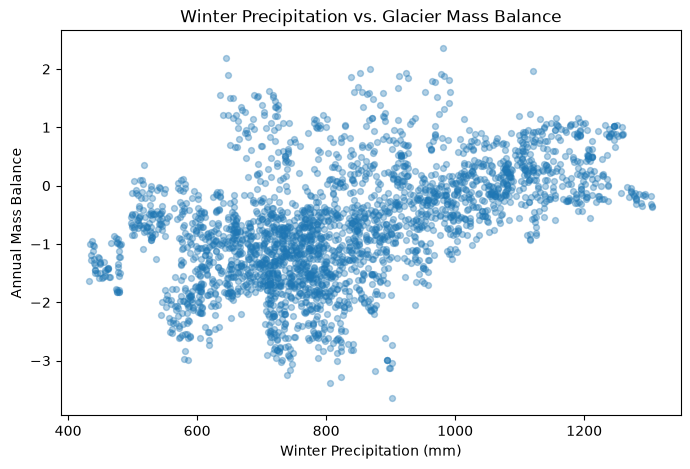

In [24]:
# Compare winter precipitation with glacier mass balance.
plt.figure(figsize=(8, 5))

plt.scatter(
    data["winter_precipitation_mm"],
    data["mass_balance"],
    alpha=0.35,
    s=18
)

plt.xlabel("Winter Precipitation (mm)")
plt.ylabel("Annual Mass Balance")
plt.title("Winter Precipitation vs. Glacier Mass Balance")

plt.show()

### Winter Precipitation

Higher winter precipitation generally lines up with higher glacier mass balance. There is still a lot of variation at similar precipitation levels, so winter precipitation is useful but does not explain mass balance by itself.

## Compare Mass Balance Between Glaciers

Mass balance is compared across glacier records to see whether some glaciers consistently gain or lose more mass than others. Large differences would suggest that climate alone may not capture all of the variation between glaciers.

In [25]:
# Calculate the average mass balance for each glacier record.
glacier_mean_smb = (
    data.groupby("glacier_index")
    .agg(
        glacier_name=("glacier_name", "first"),
        mean_mass_balance=("mass_balance", "mean"),
        observations=("mass_balance", "count")
    )
    .sort_values("mean_mass_balance")
)

print(glacier_mean_smb["mean_mass_balance"].describe())

print("\nLowest average mass balance:")
print(glacier_mean_smb.head(5))

print("\nHighest average mass balance:")
print(glacier_mean_smb.tail(5))

count    58.000000
mean     -0.715926
std       0.147753
min      -1.165555
25%      -0.792269
50%      -0.695775
75%      -0.595945
max      -0.399878
Name: mean_mass_balance, dtype: float64

Lowest average mass balance:
                glacier_name  mean_mass_balance  observations
glacier_index                                                
490                du Mort 1          -1.165555            48
489                du Mort 2          -1.074670            48
534            de la Thendia          -1.006196            48
491                du Mort 3          -0.966160            48
535            de Trelaporte          -0.954368            48

Highest average mass balance:
                   glacier_name  mean_mass_balance  observations
glacier_index                                                   
574            de Pierre Joseph          -0.562170            48
447                  du Miage 3          -0.536101            48
464                 du Bourgeat          -0.526635   

### Differences Between Glaciers

Average mass balance does vary between glacier records, ranging from about -1.17 to -0.40. These differences are smaller than the overall year-to-year variation in mass balance, but they show that the glaciers do not all respond exactly the same way. Glacier characteristics may help explain some of this remaining variation and should be considered during feature selection.

## Baseline Climate Feature Test

A simple baseline model is used to compare different climate feature sets before final feature selection. Later years are kept separate from the training data so the comparison better represents forecasting future glacier conditions.

In [26]:
# Split the data by year instead of randomly mixing glacier-year observations.
train_data = data[data["hydrological_year"] <= 2005].copy()
test_data = data[data["hydrological_year"] >= 2006].copy()

print(
    "Training years:",
    train_data["hydrological_year"].min(),
    "-",
    train_data["hydrological_year"].max()
)

print(
    "Testing years:",
    test_data["hydrological_year"].min(),
    "-",
    test_data["hydrological_year"].max()
)

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

print(
    "Years shared between sets:",
    len(
        set(train_data["hydrological_year"])
        & set(test_data["hydrological_year"])
    )
)

Training years: 1968 - 2005
Testing years: 2006 - 2015
Training rows: 2194
Testing rows: 530
Years shared between sets: 0


### Baseline Feature Adjustment

The first baseline test included all six climate features. After checking the features, the annual values were found to repeat information already included in the seasonal values. The annual features were removed from the final comparison, leaving the seasonal temperature and precipitation values for the baseline.

Temperature and precipitation use very different units and ranges, so the selected climate features are standardized before fitting the baseline model. This keeps the inputs on a comparable scale while preserving the same train and test years.

In [27]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

feature_sets = {
    "Summer Temperature": [
        "summer_temperature_c"
    ],

    "Summer Temp + Winter Precip": [
        "summer_temperature_c",
        "winter_precipitation_mm"
    ],

    "Seasonal Climate": [
        "winter_temperature_c",
        "summer_temperature_c",
        "winter_precipitation_mm",
        "summer_precipitation_mm"
    ]
}

results = []

for name, features in feature_sets.items():

    X_train = train_data[features]
    X_test = test_data[features]

    y_train = train_data["mass_balance"]
    y_test = test_data["mass_balance"]

    model = make_pipeline(
        StandardScaler(),
        LinearRegression()
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    results.append({
        "Feature Set": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R2": r2_score(y_test, predictions)
    })

baseline_results = pd.DataFrame(results)

baseline_results.round(3)

,Feature Set,MAE,RMSE,R2
0,Summer Temperature,0.632,0.750,-0.075
1,Summer Temp + Winter Precip,0.556,0.654,0.184
2,Seasonal Climate,0.473,0.570,0.379
